<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/ecg-classification-resnet/blob/main/Confidence_Penalty_Loss_RESNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D, Add, Input, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"  # FIXED

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Mounted at /content/drive
Train shape: (87554, 188)
Test shape: (21892, 188)


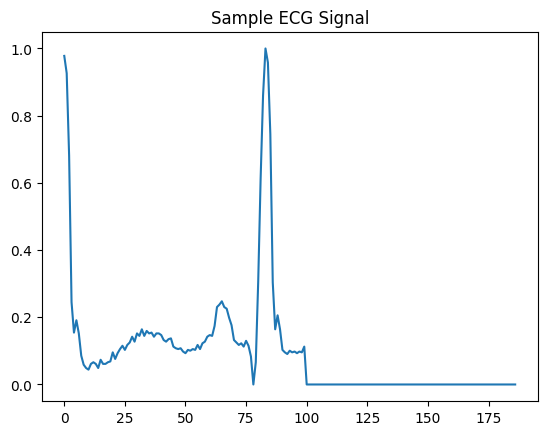

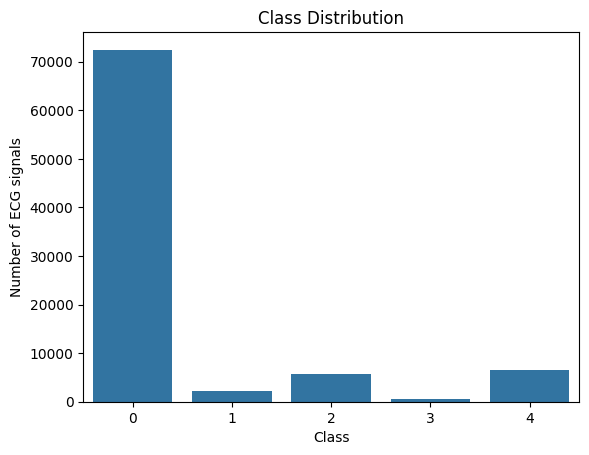

0
0


In [ ]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)
plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

print(train.isna().sum().sum())
print(test.isna().sum().sum())

In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
X_res = np.array(X_res).reshape(-1, 187, 1)
X_test = np.array(X_test).reshape(-1, 187, 1)

In [ ]:
# Convert to one-hot
y_res_cat = to_categorical(y_res, 5)
y_test_cat = to_categorical(y_test, 5)

# Convert to -1 / +1 (required for hinge loss)
y_res_cat = 2 * y_res_cat - 1
y_test_cat = 2 * y_test_cat - 1

In [ ]:
def confidence_penalty(y_true, y_pred):

    ce = tf.keras.losses.categorical_crossentropy(
        y_true, y_pred
    )

    p = tf.nn.softmax(y_pred)
    entropy = -tf.reduce_sum(
        p * tf.math.log(p + 1e-10),
        axis=1
    )

    return ce - 0.1 * entropy

In [ ]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x


def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32,3,activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x,64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128,activation='relu')(x)

    # IMPORTANT: linear activation for hinge
    outputs = Dense(5, activation='linear')(x)

    model = Model(inputs,outputs)

    model.compile(
    optimizer='adam',
    loss=confidence_penalty,
    metrics=['accuracy']
)

    return model

In [ ]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [ ]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = resnet_ecg()

    model.fit(X_tr, y_tr, epochs=5, batch_size=64, verbose=1)

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)

print("\nMean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 57s 11ms/step - accuracy: 0.2072 - loss: -30.3893
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.2113 - loss: -29.7360
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.1977 - loss: -29.8458
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.2326 - loss: -29.7726
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.2216 - loss: -29.8684
Fold 1 Accuracy: 0.1866

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 52s 11ms/step - accuracy: 0.2233 - loss: -29.0941
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.2418 - loss: -29.9784
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.2494 - loss: -29.6841
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.2383 - loss: -30.2341
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.2306 - loss: -29.8910
Fold 2 Accuracy: 0.1929

Fold 3
Epoch 1/5
3775/3775 ━━━━━━

In [ ]:
model = resnet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 68s 12ms/step - accuracy: 0.1448 - loss: -32.6713 - val_accuracy: 0.2155 - val_loss: -40.0270
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - accuracy: 0.2361 - loss: -29.0852 - val_accuracy: 0.2688 - val_loss: -31.0584
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.2547 - loss: -30.3187 - val_accuracy: 0.2390 - val_loss: -29.7693
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.2178 - loss: -30.1526 - val_accuracy: 0.1519 - val_loss: -29.7486
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.2121 - loss: -30.1253 - val_accuracy: 0.1836 - val_loss: -29.5944
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.2499 - loss: -29.8138 - val_accuracy: 0.2951 - val_loss: -29.8590
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.2263 - loss: -29.4653 - val_accuracy: 0.2189 - val_loss: -29.7375
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10

In [ ]:
# Convert predictions back properly
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax((y_val_final + 1)//2, axis=1)

mcc_val = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc_val)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
Validation MCC: 0.0


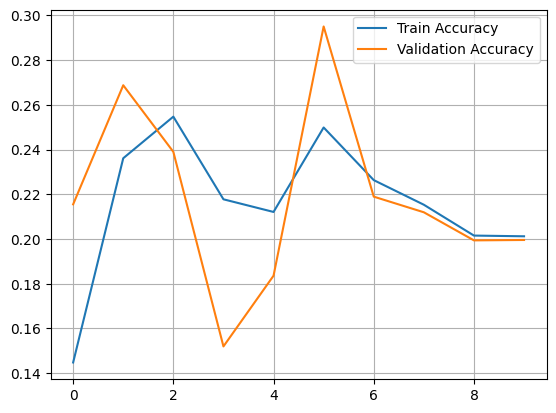

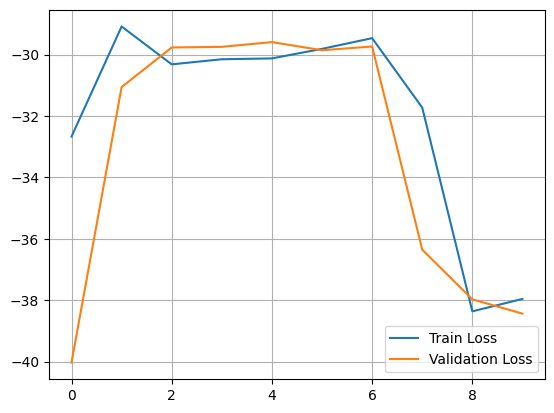

In [ ]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_test_pred = np.argmax(model.predict(X_test), axis=1)
y_test_true = np.argmax((y_test_cat + 1)//2, axis=1)

print(classification_report(y_test_true, y_test_pred))

Test Accuracy: 0.8276
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.83      1.00      0.91     18118
           1       0.00      0.00      0.00       556
           2       0.00      0.00      0.00      1448
           3       0.00      0.00      0.00       162
           4       0.00      0.00      0.00      1608

    accuracy                           0.83     21892
   macro avg       0.17      0.20      0.18     21892
weighted avg       0.68      0.83      0.75     21892



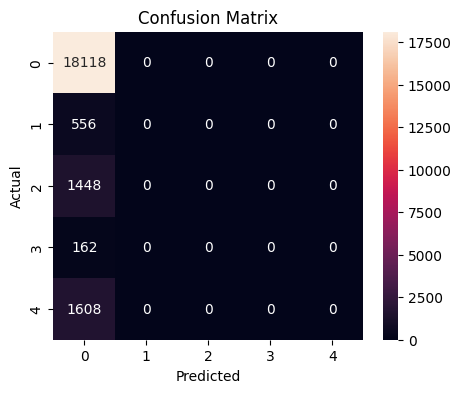

In [ ]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()